* Extract words from all the emails.
* Is alpha extraction from the email words.
* get frequency of the words in the email.
* Remove " " from the email words.
* Get the top 3000 words from the email.
* Create tabular data for the top 3000 words for the email words. 


In [1]:
# Get the data from the dataset

import pandas as pd

# Get the data from the csv file.
data = pd.read_csv("Dataset/combined_spam.csv")

data.head()

,text,label
0,urgent! your mobile number has been awarded wi...,spam
1,how do you guys go to see movies on your side.,ham
2,"sorry,in meeting i'll call later",ham
3,you didn't have to tell me that...now i'm thin...,ham
4,kindly send some one to our flat before &lt;de...,ham


In [2]:
# Finding NA Rows

na_rows = data[data.isna().any(axis=1)]
print(na_rows)
len(na_rows)       

Empty DataFrame
Columns: [text, label]
Index: []


0

In [3]:
# Check Cleaned dataframe for null values

data_clean = data.dropna()
data_clean_na_rows = data_clean[data_clean.isna().any(axis=1)]
print(data_clean_na_rows)
len(data_clean_na_rows)

Empty DataFrame
Columns: [text, label]
Index: []


0

In [4]:
# Extract all the words

words = []
for row in data_clean['text']:
    words +=  row.split(" ")

len(words)

1895809

In [5]:
# Make Non Alphabet words as empty

for i in range(len(words)):
    if not words[i].isalpha():
        words[i] = ""

In [6]:
# Make Frequency Dictionary for the words

from collections import Counter

word_dict = Counter(words)

del word_dict['']

print(len(word_dict))
print(word_dict)

34053
Counter({'the': 49986, 'to': 42594, 'and': 27247, 'of': 23333, 'a': 20568, 'you': 20363, 'i': 19280, 'in': 18129, 'for': 16920, 'enron': 13382, 'is': 12932, 'on': 12931, 'ect': 11418, 'this': 9932, 'your': 9519, 'that': 9449, 'be': 9335, 'with': 8923, 'we': 8805, 'vince': 8532, 'will': 8322, 'have': 7887, 'at': 7087, 'it': 6941, 'from': 6826, 'are': 6741, 's': 6282, 'as': 6108, 'hou': 5577, 'by': 5540, 'if': 5471, 'or': 5388, 'com': 5360, 'am': 5185, 'please': 5038, 'me': 4933, 'kaminski': 4770, 'not': 4752, 'can': 4485, 'would': 4459, 'subject': 4429, 'my': 4342, 'our': 4334, 're': 3959, 'cc': 3896, 'j': 3755, 'an': 3663, 'pm': 3297, 'all': 3038, 'do': 2866, 'any': 2850, 'time': 2837, 'research': 2711, 'know': 2710, 'has': 2684, 'thanks': 2636, 'about': 2488, 'was': 2472, 'may': 2433, 'he': 2418, 'but': 2408, 'new': 2351, 'group': 2351, 'get': 2348, 'like': 2310, 'so': 2279, 'e': 2265, 'information': 2183, 'energy': 2167, 'one': 2146, 'more': 2139, 'up': 2130, 'risk': 2090, 'wha

In [7]:
# Keeping the top 3000 top frequent words

word_dict = word_dict.most_common(3000)
print(word_dict)

[('the', 49986), ('to', 42594), ('and', 27247), ('of', 23333), ('a', 20568), ('you', 20363), ('i', 19280), ('in', 18129), ('for', 16920), ('enron', 13382), ('is', 12932), ('on', 12931), ('ect', 11418), ('this', 9932), ('your', 9519), ('that', 9449), ('be', 9335), ('with', 8923), ('we', 8805), ('vince', 8532), ('will', 8322), ('have', 7887), ('at', 7087), ('it', 6941), ('from', 6826), ('are', 6741), ('s', 6282), ('as', 6108), ('hou', 5577), ('by', 5540), ('if', 5471), ('or', 5388), ('com', 5360), ('am', 5185), ('please', 5038), ('me', 4933), ('kaminski', 4770), ('not', 4752), ('can', 4485), ('would', 4459), ('subject', 4429), ('my', 4342), ('our', 4334), ('re', 3959), ('cc', 3896), ('j', 3755), ('an', 3663), ('pm', 3297), ('all', 3038), ('do', 2866), ('any', 2850), ('time', 2837), ('research', 2711), ('know', 2710), ('has', 2684), ('thanks', 2636), ('about', 2488), ('was', 2472), ('may', 2433), ('he', 2418), ('but', 2408), ('new', 2351), ('group', 2351), ('get', 2348), ('like', 2310), (

In [8]:
import matplotlib.pyplot as plt

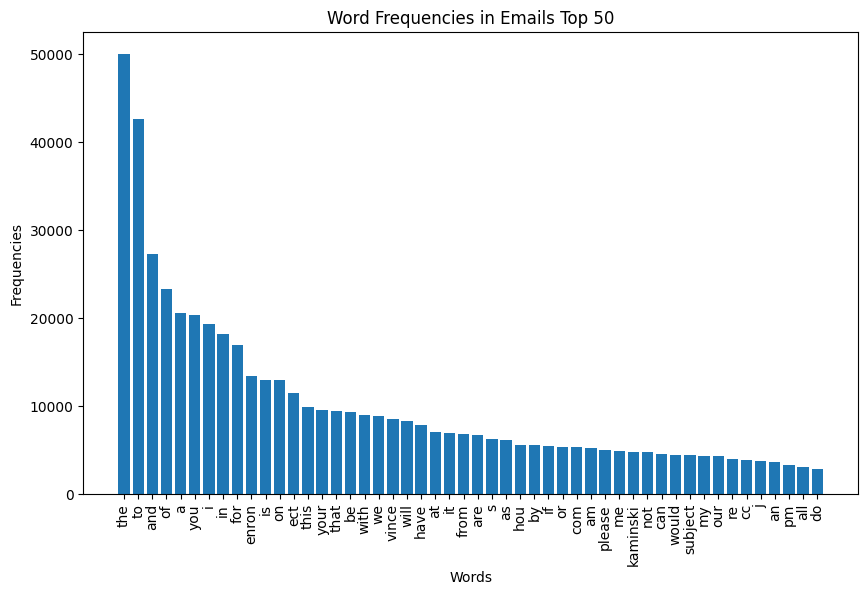

In [9]:
# Plot 50 top word frequencies
plt.figure(figsize=(10,6))

words, frequencies = zip(*word_dict[:50])

plt.bar(words, frequencies)
plt.xlabel("Words")
plt.xticks(rotation=90)
plt.ylabel("Frequencies")
plt.title("Word Frequencies in Emails Top 50")
plt.show()

In [10]:
# Creating Tabular data of Most common words in the emails

feature_matrix = []
labels = []
texts = []  # Keep original email texts

for text, label in data_clean[['text', 'label']].values:
    data_count = []    
    row_words = text.split(" ")
    for word in word_dict:
        # print(word[0])
        data_count.append(row_words.count(word[0]))
    feature_matrix.append(data_count)
    texts.append(text)  # Save original text

    if 'spam' in label:
        labels.append(1)
    if 'ham' in label:
        labels.append(0)


In [11]:
len(feature_matrix)

10774

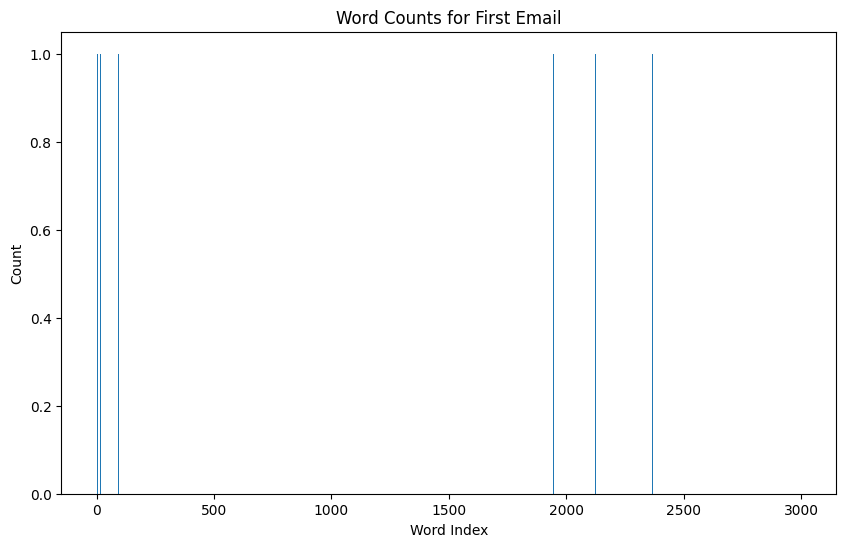

In [12]:
# Plot the data in the feature matrix
plt.figure(figsize=(10,6))
plt.bar(range(len(feature_matrix[0])), feature_matrix[0])
plt.xlabel("Word Index")
plt.ylabel("Count")
plt.title("Word Counts for First Email")
plt.show()

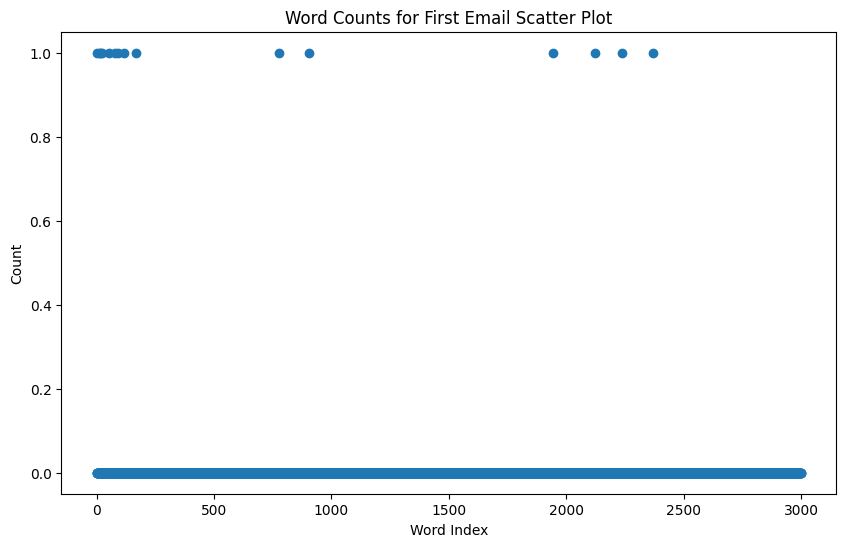

In [13]:
# Plot the data in the feature matrix in scatter plot
plt.figure(figsize=(10,6))
plt.scatter(range(len(feature_matrix[0])), feature_matrix[0])
plt.xlabel("Word Index")
plt.ylabel("Count")
plt.title("Word Counts for First Email Scatter Plot")
plt.show()

In [14]:
len(labels)

10774

In [15]:
# Convert to numpy array

import numpy as np

feature_matrix = np.array(feature_matrix)
feature_matrix.shape

(10774, 3000)

In [16]:
labels = np.array(labels)
labels.shape

(10774,)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, texts_train, texts_test = train_test_split(feature_matrix, labels, texts, test_size=0.2, random_state=9)


In [18]:
X_train.shape

(8619, 3000)

In [19]:
# Using Naive Bayes for Classification

from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()

In [20]:
classifier.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [21]:
# email = "Hi, the team saw your presentation on marketing and they were really happy when will you be free for a coffee?"
email = "You have unlocked a new offer deposit in order to claim the prize. Hurry up before the stock is empty."

In [22]:
sample = []
for word in word_dict:
    sample.append(email.split(" ").count(word[0]))

In [23]:
sample = np.array(sample)
sample.shape

(3000,)

In [24]:
classifier.predict(sample.reshape(1,3000))

array([1])

In [25]:
y_pred = classifier.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_test)

0.9215777262180974

In [27]:
from transformers import pipeline

/media/preyumkr/DATA/Beyond_College/GITHUB/Email_Spam_Classifier/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Disable CUDA

spam_roberta = pipeline("text-classification", model="dima806/email-spam-detection-roberta", device=-1)  # device=-1 means CPU
# spam_roberta = pipeline("text-classification", model="roshana1s/spam-message-classifier")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1735.33it/s]


In [32]:
y_pred_roberta = spam_roberta(texts_test, truncation=True, max_length=512)  # Truncate long texts
y_pred_roberta = [1 if pred['label'].lower() == 'spam' else 0 for pred in y_pred_roberta]


In [33]:
accuracy_score(y_pred_roberta, y_test)

0.7958236658932715

In [34]:
spam_roberta_2 = pipeline("text-classification", model="roshana1s/spam-message-classifier", device=-1)  # device=-1 means CPU
y_pred_roberta_2 = spam_roberta_2(texts_test, truncation=True, max_length=512)  # Truncate long texts
y_pred_roberta_2 = [1 if pred['label'].lower() == 'spam' else 0 for pred in y_pred_roberta_2]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21605.72it/s]


In [35]:
accuracy_score(y_pred_roberta_2, y_test)

0.8445475638051044

In [36]:
text_sample = "I love you! You are the best person in the world. I am so happy to have you in my life. You are my sunshine and my everything. I will always love you and be there for you. You are my soulmate and my best friend. I am so grateful to have you in my life. I love you more than words can express. You are the love of my life and I will always cherish you. I am so lucky to have you as my partner. I love you with all my heart and soul. You are the most amazing person I have ever met and I am so blessed to have you in my life."

In [37]:
print("Roberta 1: ",spam_roberta(text_sample, truncation=True, max_length=512))
print("Roberta 2: ",spam_roberta_2(text_sample, truncation=True, max_length=512))
sample = []
for word in word_dict:
    sample.append(text_sample.split(" ").count(word[0]))
print("Naive Bayes: ", classifier.predict(np.array(sample).reshape(1,3000)))

Roberta 1:  [{'label': 'Spam', 'score': 0.9714934825897217}]
Roberta 2:  [{'label': 'ham', 'score': 0.7302480936050415}]
Naive Bayes:  [1]


In [ ]:
# I don't know about the accuracy of the models but I think the second Roberta model is better than the first one and the Naive Bayes model. The first roberta model and the naive bayes model will lead one to lose their soul mate by classsifying the above text as spam. The second roberta model is the only one that classifies the above text as ham which is correct. So I think the second roberta model is better than the first one and the Naive Bayes model.